In [16]:
# imports the necessary libraries 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("data/DATA.CSV")

In [17]:
# Load the data
#We choose a variable name for the raw ECG data. Here we use `data`. We can check its content and shape after loading it with `numpy.genfromtxt`, 
# which auto-detects whitespace/tabs and ignores trailing blanks.

data = np.genfromtxt("data/DATA.CSV")   
print(data)
print(data.shape)

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


In [18]:
# equipment constants
GAIN_uV_per_unit = 1024      # A/D converter gain
SAMPLING_FREQ_HZ = 1000      # samples per second

# convert raw values to millivolts
#Using the A/D converter gain, we convert the raw ECG data into millivolts.
ecg_mV = data * GAIN_uV_per_unit 

# Using the sampling frequency, we convert the time axis (in samples) into seconds
n_samples = data.shape[0]
time_s = np.arange(n_samples) / SAMPLING_FREQ_HZ

print(ecg_mV.shape)
print(time_s[:5], "...", time_s[-5:])

(6500, 3)
[0.    0.001 0.002 0.003 0.004] ... [6.495 6.496 6.497 6.498 6.499]


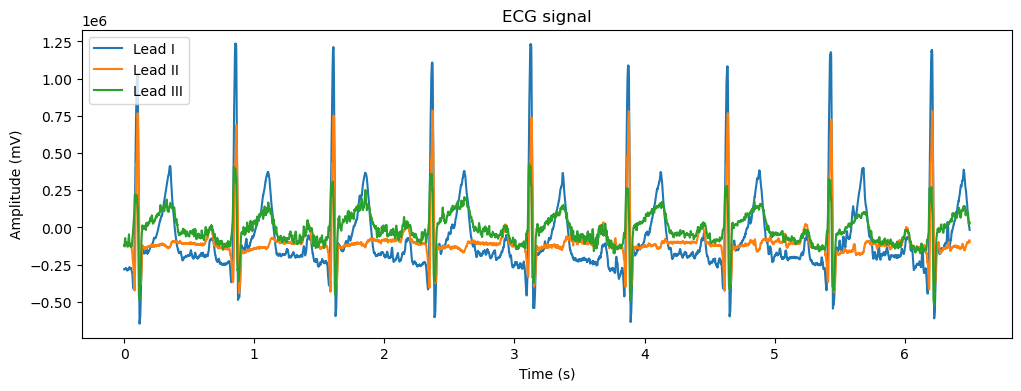

In [19]:
# plot the ECG data (all 3 leads on one plot)
#Now that the ECG data is in the correct units (mV) 
# and the time axis is in seconds, we can plot it using Matplotlib.

plt.figure(figsize=(12, 4))
plt.plot(time_s, ecg_mV)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("ECG signal")
plt.legend(["Lead I", "Lead II", "Lead III"])
plt.show()

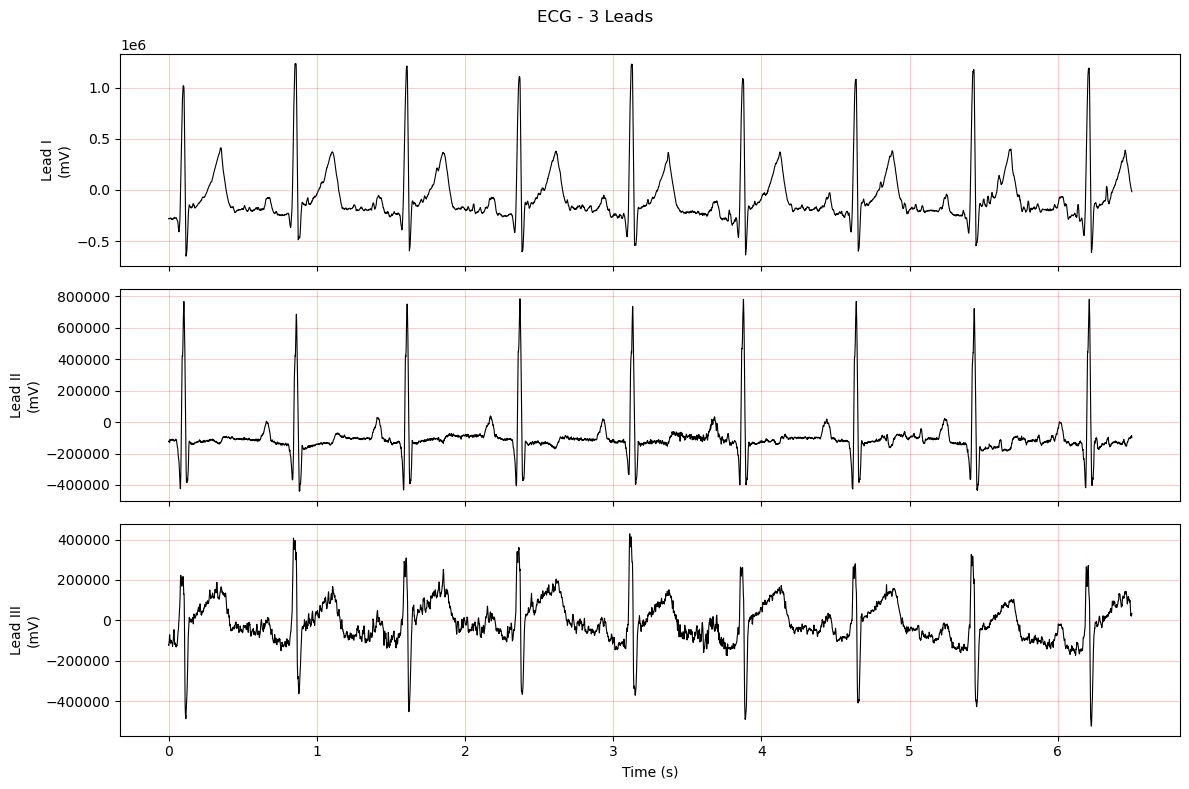

In [20]:
# realistic ECG-style plot with one subplot per lead
#We have multiple leads (I, II, III) to display. Instead of plotting them on a single graph, we create one subplot per lead to mimic the appearance of a real ECG monitor.

lead_names = ["I", "II", "III"]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(time_s, ecg_mV[:, i], color="black", linewidth=0.8)
    ax.set_ylabel(f"Lead {lead_names[i]}\n(mV)")
    ax.grid(True, which="both", color="red", alpha=0.2)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("ECG - 3 Leads")
plt.tight_layout()
plt.show()